                                         **NETFLIX MOVIE DATA ANALYSIS PROJECT**
                                          
Netflix was founded by Reed Hastings and Marc Randolph as a DVD-by-mail service. In 2007, it launched its streaming service, letting subscribers watch movies and TV shows online. By 2016, Netflix had expanded to 190 countries and now has over 283 million members worldwide.

The company is also well known for its use of data science, machine learning, and AI to build powerful recommendation systems and algorithms that understand user behavior and viewing patterns.

In [1]:
#importing imp. libraries 
import numpy as np #numerical operations and working with array
import pandas as pd #to clean  and load data , explore data in table form
import matplotlib.pyplot as plt #create you all kinds of graphs
import seaborn as sns #statistical tools


In [2]:
#read csv file 
file_path = "C:/Users/shish/Desktop/movie_dataset.csv"
df = pd.read_csv(file_path, lineterminator='\n') # consistent line ending            

# BASIC EXPLORATION 

**Top 5 rows in datasets

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

**for basic info of data(i.e datatype )

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


So from the info() , we get to know that total movie released is 9826 and there was no null value present in data .

**for duplicatee value 

In [6]:
df.duplicated().sum()

0

So we use duplicated , to check name of movie was not duplicated or same (I.e spider man 1 or spider man 2) . No movie was duplicated . 

**For Basic  Statictic description 

In [7]:
df.describe() # for numerical Data only 

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


**Shape of Dataset

In [8]:
df.shape

(9827, 9)

we have datframe of 9827 rows and 9 columns 

**Checking Datatype 

In [9]:
df.dtypes

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count             int64
Vote_Average         float64
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

Data type of date is object(String) , so we have to change in Date Time Format and duration  datatype is also in object data types , which should be in int . 

**Genre in Dataset 

In [10]:
df["Genre"]

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9822                          Drama, Crime
9823                                Horror
9824             Mystery, Thriller, Horror
9825                 Music, Drama, History
9826           War, Drama, Science Fiction
Name: Genre, Length: 9827, dtype: object

Genre column has seperated values and white spaces that needs to be handled . 

# PREPROCEESING OF DATA

**Changing of datatype of date 

In [11]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
 
print(df['Release_Date'].dtypes)

datetime64[ns]


In [12]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [13]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


So in this we convert the datatype of Release_Date 

**Dropping the columns which were not useful further analysis

In [14]:
cols = ['Overview', 'Original_Language', 'Poster_Url'] #col function - list of array of columns name that you want to drop from df

In [15]:
df.drop(cols, axis = 1, inplace = True) #inplace=True for removal of permanent columns
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


**Adding Labels in Vote Average 

In [17]:
import pandas as pd

# Define the function FIRST
def categorize_col(df, col, labels):
    """
    Categorizes a numeric column based on its quartiles.

    Args:
        df     (pd.DataFrame): The dataframe to process
        col    (str):           Column name to categorize
        labels (list):          Labels for the quartiles, from low to high

    Returns:
        pd.DataFrame: Updated dataframe with the categorized column
    """
    df[col] = pd.to_numeric(df[col], errors='coerce') # ensures column in numeric and if any value can't be converted , its turned in Nan

    # Get quartile boundaries
    edges = [
        df[col].describe()['min'], # df[col].describe()- givess statistical summary 
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    # Remove duplicate edges if any
    edges = sorted(set(edges))

    # Adjust labels length to match number of bins
    if len(labels) != len(edges) - 1:
        raise ValueError(f"Number of labels ({len(labels)}) must be one less than number of edges ({len(edges)}).")

    df[col] = pd.cut(df[col], bins=edges, labels=labels, include_lowest=True, duplicates='drop')
    return df #pd.cut() - splits the column based on edges


file_path = r"C:\Users\shish\Desktop\movie_dataset.csv"
df = pd.read_csv(file_path, lineterminator='\n')

# Categorize 'Vote_Average' into quartiles
labels = ['not_popular', 'below_avg', 'average', 'popular']
df = categorize_col(df, 'Vote_Average', labels)

# Confirm changes
print(df['Vote_Average'].unique())


['popular', 'below_avg', 'average', 'not_popular']
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']


In [18]:
df["Vote_Average"].value_counts()

Vote_Average
not_popular    2567
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

So approx 2400 movies were not popular in the dataset , so we remove the not_popular movies in dataset 

In [19]:
df.isna().sum() #df.isna().sum() - identify no. of missing Nan values in each column of dataframe

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

**dropping NaNs

In [20]:

df.dropna(inplace = True)
df.isna().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [21]:
#Turning the genre string into a list of individual genres, then separate them so that each movie appears in multiple rows—one row for each genre.

In [22]:
df['Genre'] = df['Genre'].str.split(', ')    #explode - transform a column of list into multiple rows
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
3,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Crime,https://image.tmdb.org/t/p/original/74xTEgt7R3...
4,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Mystery,https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Release_Date       25793 non-null  object  
 1   Title              25793 non-null  object  
 2   Overview           25793 non-null  object  
 3   Popularity         25793 non-null  float64 
 4   Vote_Count         25793 non-null  int64   
 5   Vote_Average       25793 non-null  category
 6   Original_Language  25793 non-null  object  
 7   Genre              25793 non-null  object  
 8   Poster_Url         25793 non-null  object  
dtypes: category(1), float64(1), int64(1), object(6)
memory usage: 1.6+ MB


In [24]:
df.nunique()

Release_Date         5893
Title                9513
Overview             9822
Popularity           8160
Vote_Count           3266
Vote_Average            4
Original_Language      43
Genre                  19
Poster_Url           9827
dtype: int64

In [25]:
df.head().T

,0,1,2,3,4
Release_Date,2021-12-15,2021-12-15,2021-12-15,2022-03-01,2022-03-01
Title,Spider-Man: No Way Home,Spider-Man: No Way Home,Spider-Man: No Way Home,The Batman,The Batman
Overview,Peter Parker is unmasked and no longer able to...,Peter Parker is unmasked and no longer able to...,Peter Parker is unmasked and no longer able to...,"In his second year of fighting crime, Batman u...","In his second year of fighting crime, Batman u..."
Popularity,5083.954,5083.954,5083.954,3827.658,3827.658
Vote_Count,8940,8940,8940,1151,1151
Vote_Average,popular,popular,popular,popular,popular
Original_Language,en,en,en,en,en
Genre,Action,Adventure,Science Fiction,Crime,Mystery
Poster_Url,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/74xTEgt7R3...,https://image.tmdb.org/t/p/original/74xTEgt7R3...


# Data Visualization

In [26]:
sns.set_style("whitegrid")

Votes vs Popularity(Do more votes always mean higher popularity?)

Text(0.5, 1.0, 'Votes vs Popularity')

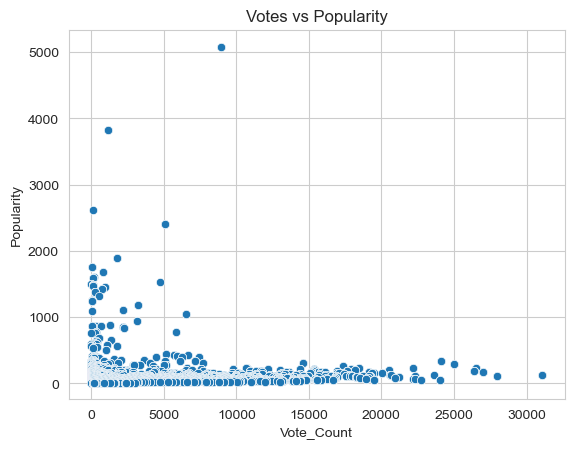

In [27]:
sns.scatterplot(data=df, x='Vote_Count', y='Popularity')
plt.title('Votes vs Popularity')


Conclusion -  The chart compares the number of votes a movie got with its popularity.Each dot is a movie.Most movies with lots of votes are not very popular.Some movies with very few votes are very popular.
There is no clear pattern that says "more votes = more popularity."Just because a movie has more votes doesn’t mean it is more popular.



What is the most frequent genre of movies relleased?

In [28]:
df["Genre"].describe()

count     25793
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

Conclusion - You are analyzing the "Genre" column in a dataset.There are 19 different genres.The most common genre is Drama.

There are 3,715 Drama movies in the dataset.

C:\Users\shish\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


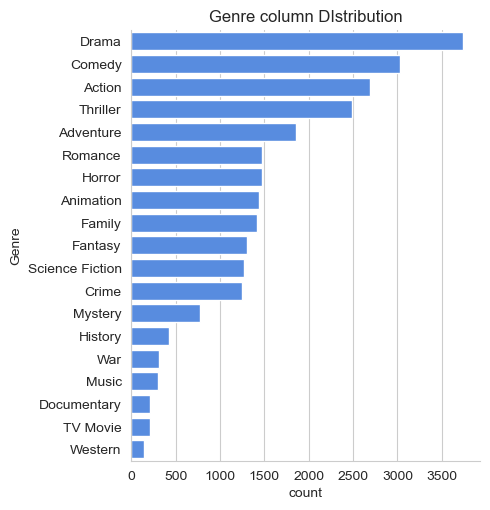

In [29]:
sns.catplot(y="Genre", data = df , kind = "count",
           order = df["Genre"].value_counts().index,
           color = "#4287f5")
plt.title("Genre column DIstribution")
plt.show()

Average Popularity by Genre

Text(0.5, 1.0, 'Average Popularity by Genre')

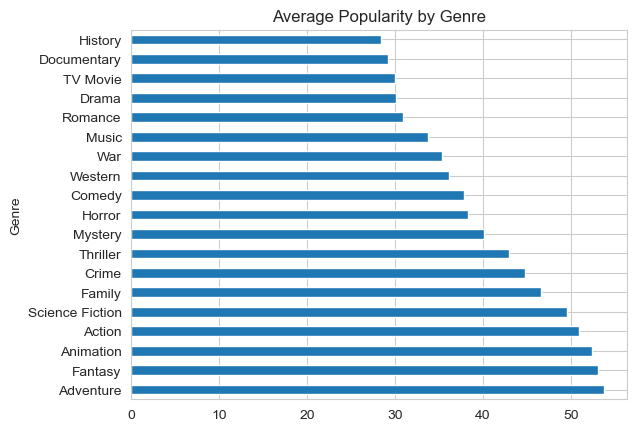

In [30]:
df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False).plot(kind='barh')
plt.title('Average Popularity by Genre')


Conclusion - The bar chart displays the average popularity of each movie genre.It issorted from most popular (at the top) to least popular (at the bottom).
Adventure is the most popular genre on average, followed closely by Fantasy, Animation, and Action.

On the other hand, genres like History, Documentary, and TV Movie have the lowest average popularity.

Which has highest votes in votes avg column?

C:\Users\shish\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


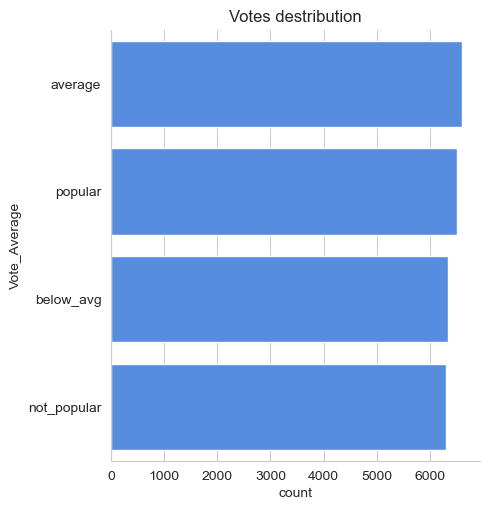

In [31]:
 sns.catplot(y = 'Vote_Average', data = df, kind = 'count', 
order = df['Vote_Average'].value_counts().index,
 color = '#4287f5')
plt.title('Votes destribution')
plt.show()

Conclusion - The chart shows how many movies fall into each Vote_Average category (like "Popular", "average", "below_avg", and "not_popular").
Each bar represents the count of movies in that category.

The categories "Popular" and "average" have the highest number of movies, followed closely by "below_avg" and "not_popular".
this means that - Most movies have average to high vote ratings.There are fewer movies that are considered not popular based on vote average.

What movie got the highest popularity ? what is it's Genre?

In [32]:
 df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...


Conclusion - Spider-Man: No Way Home” is the most popular movie in the dataset, with very high popularity and vote count
It has a popularity score of 5083.954, which is the highest

What movie got the lowest  popularity ? what is it's Genre?

In [33]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
25787,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,average,en,Music,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
25788,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,average,en,Drama,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
25789,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,average,en,History,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
25790,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,popular,en,War,https://image.tmdb.org/t/p/original/lBhU4U9Eeh...
25791,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,popular,en,Drama,https://image.tmdb.org/t/p/original/lBhU4U9Eeh...
25792,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


Conclusion -  The United States vs. Billie Holiday and Threads	are the most least popular movie in the dataset, with very least popularity and vote count
It has a popularity score of 13.354 , which is the lowest 

Which year has most filmed movies ?

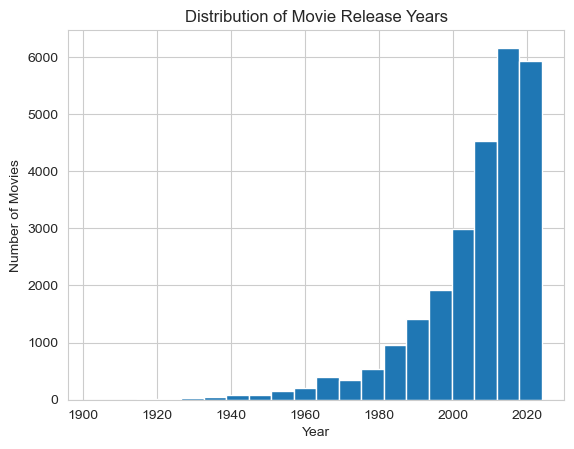

In [34]:
#''''df["Release_Date"].hist()
#plt.title('Release_Date column distribution')
#plt.show()''''
import pandas as pd
import matplotlib.pyplot as plt

# Convert Release_Date column to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

# Extract the year
df['Release_Year'] = df['Release_Date'].dt.year

# Plot histogram
df['Release_Year'].dropna().astype(int).hist(bins=20)
plt.title('Distribution of Movie Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()


Conclusion - The most movies were released in recent years, especially after 2010, with a peak around 2020.
This means that the 2020s decade (or the year 2020–2021) has the highest number of movies in the dataset.
Movie production has increased over the years.
Easier access to technology, streaming platforms, and global audiences might have led to more films being produced recently.

Genre Trends Over Time

Text(0.5, 1.0, 'Genre Trends Over Years')

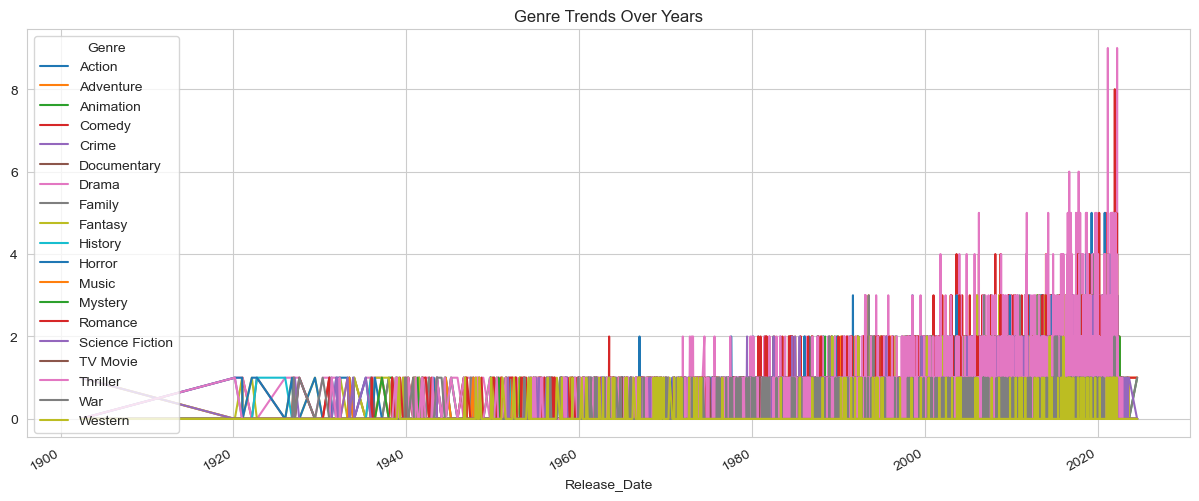

In [35]:
df_trend = df.groupby(['Release_Date', 'Genre']).size().unstack().fillna(0)
df_trend.plot(kind='line', figsize=(15, 6))
plt.title('Genre Trends Over Years')


What the chart shows:Each colored line represents a different genre.The x-axis shows the release year of movies (from 1900 to 2025).The y-axis shows the number of movies released each year in that genre.

Concliosn - Drama, Comedy, and Action are the most frequently released genres, especially in the recent years.
            2.Genres like Adventure, Thriller, Crime, and Science Fiction show consistent and moderate growth.
            3.Genres such as War, Western, History, and TV Movie remain low throughout the years.
            4.There’s a visible drop-off after 2020 in nearly all genres.

Vote Count Distribution

(0.0, 5000.0)

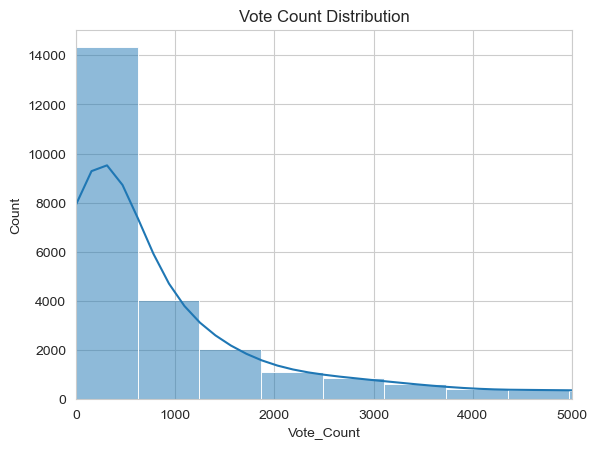

In [36]:
sns.histplot(df['Vote_Count'], bins=50, kde=True)
plt.title('Vote Count Distribution')
plt.xlim(0, 5000)


Most movies receive fewer votes, with a sharp drop as vote count increases.A majority of movies have less than 1,000 votes, while only a few receive very high engagement.This shows that only a small set of movies become widely rated, possibly due to high visibility or franchise popularity.

Movie Popularity Timeline (Yearly Top Picks)

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_top.sort_values('Release_Date'), 
            x='Release_Date', y='Popularity', palette='magma')

plt.xticks(rotation=90)
plt.title('Most Popular Movie by Year')
plt.ylabel('Popularity Score')
plt.xlabel('Release Year')
plt.tight_layout()
plt.show()



NameError: name 'yearly_top' is not defined

<Figure size 1200x600 with 0 Axes>

From 1900s to 1980s, popularity scores are near zero.This reflects:Older movies have less digital footprint or engagement.Possibly fewer votes or streaming data

The highest popularity scores by far are concentrated in 2021 and 2022.Titles from these years (e.g., Spider-Man: No Way Home) have skyrocketing popularity, likely due to:
a)Global streaming access b) Social media buzz c)Franchise blockbusters d)More Netflix originals

Correlation Analysis . (To check relationships between numeric features)

In [ ]:
file_path = r"C:\Users\shish\Desktop\Netflix Data analysis\movie_dataset .csv"

df = pd.read_csv(file_path, lineterminator='\n')   
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Encode Vote_Average back to numeric if it's still categorical
df['Vote_Avg_Numeric'] = df['Vote_Average'].map({
    'not_popular': 1,
    'below_avg': 2,
    'average': 3,
    'popular': 4
})

corr = df[['Popularity', 'Vote_Count', 'Vote_Avg_Numeric']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Conclusion: Popularity on Netflix is not strongly related to how many people vote or how well a movie is rated — it's likely influenced more by factors like marketing, release timing, and franchise buzz.

Popularity and Vote Count have a very weak positive correlation (0.14), suggesting that movies with more votes may be slightly more popular, but it's not a strong trend.

Vote_Average (rating) has almost no relationship with either popularity or vote count. This means a movie’s popularity is not driven by its quality rating.

# EDA CONCLUSION 

 --->Total movie released was 9826 and there was no null value present in dataset .
 
 --->No movie name was duplicated .
 
 ---> In the dataset we have 9827 rows and 9 columns
 
 --->The majority fall movies  under popular (2,450) and average (2,412) categories, while not_popular movies still account for a significant portion (2,467).
 
 --->There are 19 different genres& the most common genre is Drama.There are 3,715 Drama movies in the dataset.
 
 ---> Spider-Man: No Way Home” is the most popular movie in the dataset, with very high popularity and vote count It has a popularity score of 5083.954, which is the highest.
 
 --->The United States vs. Billie Holiday and Threads are the most least popular movie in the dataset, with very least popularity and vote count It has a popularity score of 13.354 , which is the lowest.
 
--->Movie production increased very quickly  after 2010, peaking around 2020–2021, likely driven by streaming platforms and global accessibility.

--->Drama, Comedy, and Action are the most frequently released genres; Adventure and Sci-Fi have shown steady growth, while others like War and History remain less popular.

--->Recent movies (2021–2022) have the highest popularity, boosted by franchises, social media buzz, and Netflix originals, whereas older films (pre-1980) have very low visibility.

---> Popularity is not strongly tied to votes or ratings.Movies with more votes may be slightly more popular, but ratings have almost no impact on popularity.

This suggests that external factors like marketing, timing, and franchises play a bigger role in making a movie popular on Netflix.
